# VaR, CVaR, and Sector Stress Test

This notebook follows the project guidance: user inputs are `start_date`, `end_date`, `tau`,
`d`, `delta`, and `alpha`; calendar dates are mapped onto a trading-day price series; and
historical horizon returns are sampled every `delta` trading days.


In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.6f}".format)


## User Inputs

`tau` and `delta` are counted in trading days after the calendar has been cleaned. Typical
rolling steps are daily `1`, weekly `5`, monthly `22`, and quarterly `66`.

`alpha` may be entered as a tail probability (`0.05`) or as a confidence level (`0.95`).


In [32]:
# Dates can be any calendar dates within the available data range.
start_date = "2005-12-31"
end_date = "2024-12-31"

# Risk parameters
tau = 252          # investment horizon in trading days
delta = 22        # rolling step in trading days
alpha = 0.05      # tail probability; 0.05 means 95% VaR
d = 20            # number of funds selected from the 50-fund universe

# Portfolio and sampling settings
initial_value = 1_000_000
universe_size = 50
random_seed = 123


## Load Data and Build a Trading Calendar

The raw files contain one row per calendar day. Weekends and holidays are represented by
unchanged prices, so the trading calendar is built by keeping the first row whenever the full
price vector changes from the previous calendar day.


In [33]:
DATA_DIR = Path("data")

EQUITY_PRICE_FILE = "us_equity_adj_close.csv"
BOND_PRICE_FILE = "us_bond_intermediate_core_adj_close.csv"
EQUITY_SECTOR_FILE = "us_equity_sectors.csv"
BOND_SECTOR_FILE = "us_bond_intermediate_fixed_income_primary_sector.csv"


def load_price_file(file_name: str) -> pd.DataFrame:
    prices = pd.read_csv(DATA_DIR / file_name, index_col="as_of", parse_dates=True)
    prices = prices.sort_index()
    prices.index.name = "as_of"
    return prices


raw_equity_prices = load_price_file(EQUITY_PRICE_FILE)
raw_bond_prices = load_price_file(BOND_PRICE_FILE)

combined_raw_prices = pd.concat([raw_equity_prices, raw_bond_prices], axis=1).sort_index()
row_hash = pd.util.hash_pandas_object(combined_raw_prices, index=False)
trading_day_mask = row_hash.ne(row_hash.shift())
trading_calendar = combined_raw_prices.index[trading_day_mask]

equity_prices = raw_equity_prices.loc[trading_calendar]
bond_prices = raw_bond_prices.loc[trading_calendar]
all_prices = pd.concat([equity_prices, bond_prices], axis=1)

print(f"Raw calendar rows: {len(combined_raw_prices):,}")
print(f"Trading-day rows: {len(all_prices):,}")
print(f"Trading date range: {all_prices.index.min().date()} to {all_prices.index.max().date()}")
display(all_prices.head())


Raw calendar rows: 9,133
Trading-day rows: 8,587
Trading date range: 1999-12-31 to 2024-12-31


,B13779,B14678,B09156,B25037,B19389,B19569,B23689,B13231,B23166,B06011,...,B11231,B14035,B01206,B23147,B07393,B12216,B23177,B08486,B26001,B15791
as_of,,,,,,,,,,,,,,,,,,,,,
1999-12-31,20.288500,NaN,18.956700,NaN,"7,827.790000",NaN,17.531100,NaN,NaN,26.751700,...,NaN,NaN,NaN,NaN,11.838200,54.140800,9.958440,33.970600,11.493800,10.023000
2000-01-01,20.288500,NaN,18.956700,NaN,"7,827.790000",NaN,17.531100,NaN,NaN,26.751700,...,NaN,NaN,NaN,NaN,11.838200,54.140800,9.958440,33.970600,11.493800,10.023000
2000-01-03,20.288500,NaN,18.320600,NaN,"7,704.460000",NaN,17.217800,NaN,NaN,26.319300,...,NaN,NaN,NaN,NaN,11.801500,53.968900,9.928050,33.779200,11.445500,10.002800
2000-01-04,20.288500,NaN,17.997400,NaN,"7,418.310000",NaN,16.789700,NaN,NaN,25.562700,...,NaN,NaN,NaN,NaN,11.813700,54.008900,9.958440,33.850800,11.469700,10.023000
2000-01-05,20.288500,NaN,18.091200,NaN,"7,421.600000",NaN,16.862800,NaN,NaN,25.778900,...,NaN,NaN,NaN,NaN,11.764800,53.778100,9.928050,33.725200,11.433500,10.002800


## Core Functions

The date mapper uses nearest available trading dates inside the data range. For example, a
Saturday start date maps forward to the next trading day, while a Saturday end date maps
backward to the previous trading day.


In [35]:
def map_to_trading_date(date_like, calendar: pd.DatetimeIndex, side: str) -> pd.Timestamp:
    """Map a calendar date to a trading date.

    side='start' maps forward to the next available trading day.
    side='end' maps backward to the previous available trading day.
    """
    date = pd.Timestamp(date_like).normalize()
    if side == "start":
        pos = calendar.searchsorted(date, side="left")
        if pos >= len(calendar):
            raise ValueError(f"start_date {date.date()} is after the last available trading date.")
        return calendar[pos]
    if side == "end":
        pos = calendar.searchsorted(date, side="right") - 1
        if pos < 0:
            raise ValueError(f"end_date {date.date()} is before the first available trading date.")
        return calendar[pos]
    raise ValueError("side must be 'start' or 'end'.")


def resolve_alpha(alpha_value: float) -> tuple[float, float]:
    # Return (tail_probability, confidence_level).
    if not 0 < alpha_value < 1:
        raise ValueError("alpha must be between 0 and 1.")
    if alpha_value <= 0.5:
        tail_probability = alpha_value
        confidence_level = 1 - alpha_value
    else:
        confidence_level = alpha_value
        tail_probability = 1 - alpha_value
    return tail_probability, confidence_level


def validate_inputs(d: int, tau: int, delta: int, universe_size: int) -> None:
    if not 1 <= d <= universe_size:
        raise ValueError(f"d must satisfy 1 <= d <= {universe_size}.")
    if tau < 1:
        raise ValueError("tau must be a positive integer number of trading days.")
    if delta < 1:
        raise ValueError("delta must be a positive integer number of trading days.")


def window_positions(prices: pd.DataFrame, start_date, end_date, tau: int, delta: int):
    calendar = prices.index
    mapped_start = map_to_trading_date(start_date, calendar, "start")
    mapped_end = map_to_trading_date(end_date, calendar, "end")
    start_pos = calendar.get_loc(mapped_start)
    end_pos = calendar.get_loc(mapped_end)
    n_obs = end_pos - start_pos + 1
    L = (n_obs - tau - 1) // delta + 1
    if L < 1:
        raise ValueError(
            "The selected date window is too short. "
            f"Need at least tau+1={tau + 1} trading-day prices; got {n_obs}."
        )
    start_positions = start_pos + np.arange(L) * delta
    end_positions = start_positions + tau
    return mapped_start, mapped_end, start_positions, end_positions


def eligible_symbols(prices: pd.DataFrame, start_positions: np.ndarray, end_positions: np.ndarray) -> list[str]:
    needed_positions = np.unique(np.r_[start_positions, end_positions])
    needed_prices = prices.iloc[needed_positions]
    valid = needed_prices.notna().all(axis=0)
    positive = (needed_prices > 0).all(axis=0)
    return prices.columns[valid & positive].tolist()


def choose_universe_and_portfolio(
    prices: pd.DataFrame,
    start_positions: np.ndarray,
    end_positions: np.ndarray,
    d: int,
    universe_size: int = 50,
    random_seed: int | None = None,
):
    symbols = eligible_symbols(prices, start_positions, end_positions)
    actual_universe_size = min(universe_size, len(symbols))
    if len(symbols) < universe_size:
        print(
            f"Warning: only {len(symbols)} funds have complete data in this window; "
            f"using a {actual_universe_size}-fund universe instead of {universe_size}."
        )
    if d > actual_universe_size:
        raise ValueError(
            f"d={d} is larger than the {actual_universe_size} funds with complete data "
            "in the selected date window. Shorten the window, reduce tau, or reduce d."
        )
    rng = np.random.default_rng(random_seed)
    universe = rng.choice(symbols, size=actual_universe_size, replace=False).tolist()
    portfolio = rng.choice(universe, size=d, replace=False).tolist()
    return universe, portfolio


def historical_return_distribution(
    prices: pd.DataFrame,
    symbols: list[str],
    start_positions: np.ndarray,
    end_positions: np.ndarray,
) -> pd.DataFrame:
    start_prices = prices.iloc[start_positions][symbols].reset_index(drop=True)
    end_prices = prices.iloc[end_positions][symbols].reset_index(drop=True)
    returns = end_prices / start_prices - 1
    returns.index = prices.index[start_positions]
    returns.index.name = "start_date"
    returns["horizon_end_date"] = prices.index[end_positions]
    return returns


def portfolio_distribution(fund_returns: pd.DataFrame, symbols: list[str]) -> pd.DataFrame:
    out = pd.DataFrame(index=fund_returns.index)
    out["horizon_end_date"] = fund_returns["horizon_end_date"].values
    out["portfolio_return"] = fund_returns[symbols].mean(axis=1)
    return out


def var_cvar_from_returns(
    portfolio_returns: pd.Series,
    alpha: float,
    initial_value: float = 1_000_000,
) -> dict:
    tail_probability, confidence_level = resolve_alpha(alpha)
    losses = -initial_value * portfolio_returns.astype(float)
    var = losses.quantile(confidence_level, interpolation="higher")
    tail_losses = losses[losses >= var]
    cvar = tail_losses.mean()
    return {
        "tail_probability": tail_probability,
        "confidence_level": confidence_level,
        "VaR": var,
        "CVaR": cvar,
        "mean_loss": losses.mean(),
        "max_loss": losses.max(),
        "num_scenarios": len(losses),
    }


## Run VaR and CVaR Calculation


In [36]:
validate_inputs(d=d, tau=tau, delta=delta, universe_size=universe_size)

mapped_start, mapped_end, start_positions, end_positions = window_positions(
    all_prices, start_date, end_date, tau, delta
)
universe_symbols, portfolio_symbols = choose_universe_and_portfolio(
    all_prices,
    start_positions,
    end_positions,
    d=d,
    universe_size=universe_size,
    random_seed=random_seed,
)

fund_return_distribution = historical_return_distribution(
    all_prices, portfolio_symbols, start_positions, end_positions
)
portfolio_return_distribution = portfolio_distribution(fund_return_distribution, portfolio_symbols)
risk_result = var_cvar_from_returns(
    portfolio_return_distribution["portfolio_return"],
    alpha=alpha,
    initial_value=initial_value,
)

print(f"Input start_date={start_date} mapped to trading date {mapped_start.date()}")
print(f"Input end_date={end_date} mapped to trading date {mapped_end.date()}")
print(f"tau={tau}, delta={delta}, scenarios={risk_result['num_scenarios']}")
print(f"alpha input={alpha}; confidence level used={risk_result['confidence_level']:.2%}")
print(f"Selected portfolio symbols ({len(portfolio_symbols)}): {portfolio_symbols}")

risk_table = pd.Series(risk_result, name="value").to_frame()
display(risk_table)
display(portfolio_return_distribution.head())


Input start_date=2005-12-31 mapped to trading date 2005-12-31
Input end_date=2024-12-31 mapped to trading date 2024-12-31
tau=252, delta=22, scenarios=303
alpha input=0.05; confidence level used=95.00%
Selected portfolio symbols (20): ['B13779', 'B06905', 'B13582', 'B15791', 'B08417', 'B09934', 'B12375', 'B00725', 'B02032', 'B02943', 'B12216', 'B01206', 'B01060', 'B12752', 'B05847', 'B05924', 'B03459', 'B01061', 'B03784', 'B11079']


,value
tail_probability,0.050000
confidence_level,0.950000
VaR,"131,205.635966"
CVaR,"189,486.185821"
mean_loss,"-56,403.226581"
max_loss,"268,710.707985"
num_scenarios,303.000000


,horizon_end_date,portfolio_return
start_date,,
2005-12-31,2006-09-09,0.030700
2006-01-22,2006-10-01,0.034045
2006-02-13,2006-10-23,0.057844
2006-03-07,2006-11-14,0.069350
2006-03-29,2006-12-06,0.064632


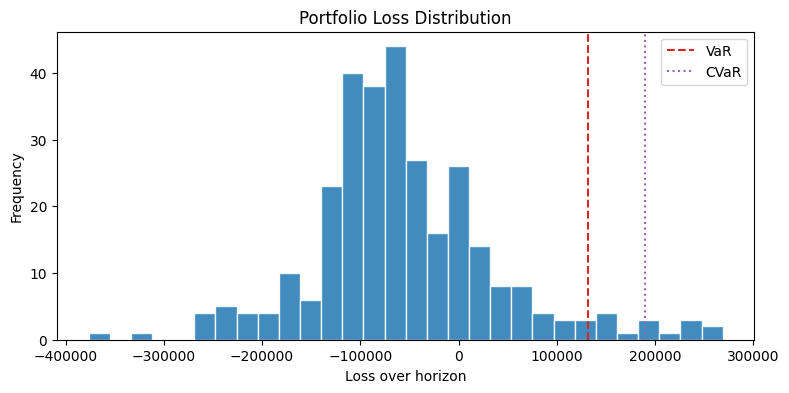

In [37]:
losses = -initial_value * portfolio_return_distribution["portfolio_return"]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(losses, bins=30, edgecolor="white", alpha=0.85)
ax.axvline(risk_result["VaR"], color="tab:red", linestyle="--", label="VaR")
ax.axvline(risk_result["CVaR"], color="tab:purple", linestyle=":", label="CVaR")
ax.set_title("Portfolio Loss Distribution")
ax.set_xlabel("Loss over horizon")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()


## Stress Test

The guidance says sector stress tests would be applied to underlying holdings. These files do
not include security-level holdings, so this notebook uses the available fund-level sector
exposures as a proxy. A shock of `-0.10` to a sector changes each fund's horizon return by:

`fund_return + sector_exposure_weight * shock`.

For equity funds, sectors come from `us_equity_sectors.csv`; for bond funds, primary sectors
come from `us_bond_intermediate_fixed_income_primary_sector.csv`.


In [38]:
def load_latest_sector_exposure(file_name: str, selected_symbols: list[str], as_of_date) -> pd.DataFrame:
    sectors = pd.read_csv(DATA_DIR / file_name)
    sectors["as_of"] = pd.to_datetime(sectors["as_of"])
    as_of_month = pd.Timestamp(as_of_date).to_period("M").to_timestamp()
    sectors = sectors[(sectors["ask_id"].isin(selected_symbols)) & (sectors["as_of"] <= as_of_month)]
    if sectors.empty:
        return pd.DataFrame(index=selected_symbols)

    sectors = sectors.sort_values(["ask_id", "as_of"]).groupby("ask_id").tail(1)
    exposure_cols = [c for c in sectors.columns if c not in {"as_of", "ask_id"}]
    out = sectors.set_index("ask_id")[exposure_cols].astype(float) / 100.0
    return out.reindex(selected_symbols).fillna(0.0)


def portfolio_sector_exposure(selected_symbols: list[str], as_of_date) -> pd.Series:
    equity_symbols = [s for s in selected_symbols if s in equity_prices.columns]
    bond_symbols = [s for s in selected_symbols if s in bond_prices.columns]

    pieces = []
    if equity_symbols:
        pieces.append(load_latest_sector_exposure(EQUITY_SECTOR_FILE, equity_symbols, as_of_date))
    if bond_symbols:
        pieces.append(load_latest_sector_exposure(BOND_SECTOR_FILE, bond_symbols, as_of_date))
    if not pieces:
        return pd.Series(dtype=float)

    exposure = pd.concat(pieces, axis=0).fillna(0.0)
    return exposure.mean(axis=0).sort_values(ascending=False)


def stress_test_sector(
    fund_returns: pd.DataFrame,
    selected_symbols: list[str],
    sector_name: str,
    shock: float,
    alpha: float,
    initial_value: float = 1_000_000,
) -> tuple[pd.DataFrame, dict]:
    equity_symbols = [s for s in selected_symbols if s in equity_prices.columns]
    bond_symbols = [s for s in selected_symbols if s in bond_prices.columns]
    equity_exposure = load_latest_sector_exposure(EQUITY_SECTOR_FILE, equity_symbols, mapped_end)
    bond_exposure = load_latest_sector_exposure(BOND_SECTOR_FILE, bond_symbols, mapped_end)
    exposure = pd.concat([equity_exposure, bond_exposure], axis=0).reindex(selected_symbols).fillna(0.0)

    if sector_name not in exposure.columns:
        valid = exposure.columns.tolist()
        raise ValueError(f"Sector '{sector_name}' not found. Valid sectors include: {valid}")

    stressed_fund_returns = fund_returns[selected_symbols].copy()
    stressed_fund_returns = stressed_fund_returns.add(exposure[sector_name] * shock, axis="columns")

    stressed_portfolio = pd.DataFrame(index=fund_returns.index)
    stressed_portfolio["horizon_end_date"] = fund_returns["horizon_end_date"].values
    stressed_portfolio["portfolio_return"] = stressed_fund_returns.mean(axis=1)
    stressed_risk = var_cvar_from_returns(
        stressed_portfolio["portfolio_return"], alpha=alpha, initial_value=initial_value
    )
    return stressed_portfolio, stressed_risk


sector_exposure = portfolio_sector_exposure(portfolio_symbols, mapped_end)
display(sector_exposure.to_frame("portfolio_weight").head(10))


,portfolio_weight
equity_econ_sector_technology_pct_net,0.116615
fixed_inc_ps_ag_mtge_bck_pct_net,0.075720
equity_econ_sector_financial_services_pct_net,0.068410
equity_econ_sector_consumer_cyclical_pct_net,0.063495
equity_econ_sector_healthcare_pct_net,0.063355
equity_econ_sector_industrials_pct_net,0.051955
equity_econ_sector_communication_services_pct_net,0.040565
fixed_inc_ps_corporate_bond_pct_net,0.035325
equity_econ_sector_consumer_defensive_pct_net,0.030785
fixed_inc_ps_gov_pct_net,0.024300


In [39]:
# Example: stress the portfolio's largest available sector by -10%.
stress_shock = -0.10
stress_sector = sector_exposure.index[0]

stressed_distribution, stressed_risk_result = stress_test_sector(
    fund_return_distribution,
    portfolio_symbols,
    sector_name=stress_sector,
    shock=stress_shock,
    alpha=alpha,
    initial_value=initial_value,
)

comparison = pd.DataFrame(
    {
        "base": risk_result,
        f"stress: {stress_sector} {stress_shock:.0%}": stressed_risk_result,
    }
)
display(comparison.loc[["VaR", "CVaR", "mean_loss", "max_loss", "num_scenarios"]])
display(stressed_distribution.head())


,base,stress: equity_econ_sector_technology_pct_net -10%
VaR,"131,205.635966","142,867.135966"
CVaR,"189,486.185821","201,147.685821"
mean_loss,"-56,403.226581","-44,741.726581"
max_loss,"268,710.707985","280,372.207985"
num_scenarios,303.000000,303.000000


,horizon_end_date,portfolio_return
start_date,,
2005-12-31,2006-09-09,0.019038
2006-01-22,2006-10-01,0.022384
2006-02-13,2006-10-23,0.046183
2006-03-07,2006-11-14,0.057689
2006-03-29,2006-12-06,0.052970
